In [363]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [364]:
data = pd.read_csv('../bitcoin_data/raw/btc_binance_daily.csv')
data.head()

,date,open,high,low,close,volume
0,2023-09-16,26599.99,26777.00,26445.00,26559.67,13960.93351
1,2023-09-17,26559.67,26623.25,26399.00,26527.51,12998.10277
2,2023-09-18,26527.50,27409.00,26377.35,26762.51,43000.43256
3,2023-09-19,26762.50,27483.57,26667.79,27210.26,36190.52187
4,2023-09-20,27210.25,27388.63,26800.00,27125.00,34207.21867


In [365]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    1000 non-null   str    
 1   open    1000 non-null   float64
 2   high    1000 non-null   float64
 3   low     1000 non-null   float64
 4   close   1000 non-null   float64
 5   volume  1000 non-null   float64
dtypes: float64(5), str(1)
memory usage: 47.0 KB


In [366]:
## take values for 3 decimal
cols = ["open", "high", "low", "close", "volume"]

data[cols] = data[cols].astype(float).round(3)

In [367]:
data["date"] = pd.to_datetime(data["date"])
data = data.sort_values("date").reset_index(drop=True)

* Take a copy of dataset

In [368]:
df = data.copy()

In [369]:
### Check duplicate values
duplicate_rows = df[df.duplicated()]

print("Number of duplicate rows:", duplicate_rows.shape[0])
print(duplicate_rows)

Number of duplicate rows: 0
Empty DataFrame
Columns: [date, open, high, low, close, volume]
Index: []


In [370]:
### Check missing values
missing_values = df.isnull().sum()
print("Number of missing values:", missing_values)

Number of missing values: date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [371]:
### Statistical overview

summary = df.drop(columns=["date"]).describe().round(3)
print(summary)

             open        high         low       close      volume
count    1000.000    1000.000    1000.000    1000.000    1000.000
mean    77163.065   78527.891   75731.818   77199.740   27660.586
std     24583.530   24836.965   24240.291   24535.328   18602.239
min     26221.680   26397.460   25990.460   26221.670    3104.117
25%     62079.002   63426.162   60653.502   62123.102   15467.079
50%     74020.460   75479.880   73080.750   74020.455   23092.700
75%     96847.298   98288.750   95208.090   96847.300   34445.785
max    124658.540  126199.630  123084.000  124658.540  162065.592


* Check zero or negative values

In [372]:
cols = ["open", "high", "low", "close", "volume"]

invalid_values = df[(df[cols] <= 0).any(axis=1)]

print(invalid_values)

Empty DataFrame
Columns: [date, open, high, low, close, volume]
Index: []


* Check Outliers

In [373]:
df["daily_return_temp"] = df["close"].pct_change()

outliers = df[abs(df["daily_return_temp"]) > 0.20]

print(outliers[["date", "close", "daily_return_temp"]])

Empty DataFrame
Columns: [date, close, daily_return_temp]
Index: []


In [374]:
df = df.sort_values("date").reset_index(drop=True)

##### Feature Engineering

* Log Return Features

In [375]:
periods = [1, 2, 5, 10]

for p in periods:
    col_name = "log_return" if p == 1 else f"log_return_{p}d"
    df[col_name] = np.log(df["close"] / df["close"].shift(p))

In [376]:
df[["log_return", "log_return_2d", "log_return_5d", "log_return_10d"]].isna().sum()

log_return         1
log_return_2d      2
log_return_5d      5
log_return_10d    10
dtype: int64

* Price Ratios

In [377]:
# Price ratios
df["high_low_ratio"] = df["high"] / df["low"]
df["close_open_ratio"] = df["close"] / df["open"]
df["high_close_ratio"] = df["high"] / df["close"]
df["low_close_ratio"] = df["low"] / df["close"]

# Daily range relative to close
df["range_ratio"] = (df["high"] - df["low"]) / df["close"]

# Candle body size relative to close
df["body_ratio"] = abs(df["close"] - df["open"]) / df["close"]

# Upper and lower shadow ratios
df["upper_shadow_ratio"] = (
    df["high"] - df[["open", "close"]].max(axis=1)
) / df["close"]

df["lower_shadow_ratio"] = (
    df[["open", "close"]].min(axis=1) - df["low"]
) / df["close"]

* Rolling Windows

In [378]:
# Rolling stats on log-return
return_windows = [7, 14, 30]

for w in return_windows:
    rolling_return = df["log_return"].rolling(window=w)

    df[f"return_mean_{w}d"] = rolling_return.mean()
    df[f"return_std_{w}d"] = rolling_return.std()
    df[f"return_skew_{w}d"] = rolling_return.skew()
    df[f"return_kurt_{w}d"] = rolling_return.kurt()

# Price distance from rolling highs / lows
price_windows = [7, 30, 90]

for w in price_windows:
    rolling_high = df["high"].rolling(window=w).max()
    rolling_low = df["low"].rolling(window=w).min()

    df[f"dist_from_high_{w}d"] = (df["close"] - rolling_high) / df["close"]
    df[f"dist_from_low_{w}d"] = (df["close"] - rolling_low) / df["close"]

In [379]:
import pandas as pd
from ta import momentum, trend


def add_momentum_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    RSI, MACD, Stochastic, ROC, Williams %R, CCI.
    Source: Jung et al. (2023) — Computer Systems Science & Engineering.
    """

    features = {}

    # RSI — multiple windows
    for w in [9, 14, 21]:
        features[f"rsi_{w}"] = momentum.RSIIndicator(
            close=df["close"],
            window=w
        ).rsi()

    # MACD
    macd_obj = trend.MACD(
        close=df["close"],
        window_slow=26,
        window_fast=12,
        window_sign=9
    )

    features["macd"] = macd_obj.macd()
    features["macd_signal"] = macd_obj.macd_signal()
    features["macd_hist"] = macd_obj.macd_diff()

    # Stochastic Oscillator
    for w in [9, 14, 21]:
        stoch_obj = momentum.StochasticOscillator(
            high=df["high"],
            low=df["low"],
            close=df["close"],
            window=w,
            smooth_window=3
        )

        features[f"stoch_k_{w}"] = stoch_obj.stoch()
        features[f"stoch_d_{w}"] = stoch_obj.stoch_signal()

    # Rate of Change — ROC
    for w in [9, 14, 21]:
        features[f"roc_{w}"] = momentum.ROCIndicator(
            close=df["close"],
            window=w
        ).roc()

    # Williams %R
    for w in [9, 14, 21]:
        features[f"williams_r_{w}"] = momentum.WilliamsRIndicator(
            high=df["high"],
            low=df["low"],
            close=df["close"],
            lbp=w
        ).williams_r()

    # Commodity Channel Index — CCI
    for w in [14, 20, 30]:
        features[f"cci_{w}"] = trend.CCIIndicator(
            high=df["high"],
            low=df["low"],
            close=df["close"],
            window=w,
            constant=0.015
        ).cci()

    feature_df = pd.DataFrame(features, index=df.index)

    return pd.concat([df, feature_df], axis=1)

In [380]:
from ta import trend


def add_trend_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    SMA, EMA, TEMA, ADX, PSAR, Ichimoku.
    """


    # Simple Moving Averages
    for w in [7, 21, 50, 200]:
        df[f"sma_{w}"] = trend.SMAIndicator(
            close=df["close"],
            window=w
        ).sma_indicator()

        df[f"price_vs_sma_{w}"] = (
            df["close"] - df[f"sma_{w}"]
        ) / df[f"sma_{w}"]

    # Exponential Moving Averages
    for w in [9, 12, 26]:
        df[f"ema_{w}"] = trend.EMAIndicator(
            close=df["close"],
            window=w
        ).ema_indicator()

    # TEMA: Triple Exponential Moving Average
    for w in [9, 12, 26]:
        ema1 = df["close"].ewm(span=w, adjust=False).mean()
        ema2 = ema1.ewm(span=w, adjust=False).mean()
        ema3 = ema2.ewm(span=w, adjust=False).mean()

        df[f"tema_{w}"] = 3 * ema1 - 3 * ema2 + ema3

    # EMA / SMA crossover features
    df["ema_9_26_cross"] = df["ema_9"] - df["ema_26"]
    df["sma_50_200_cross"] = df["sma_50"] - df["sma_200"]

    # ADX: trend strength
    adx_obj = trend.ADXIndicator(
        high=df["high"],
        low=df["low"],
        close=df["close"],
        window=14
    )

    df["adx"] = adx_obj.adx()
    df["adx_pos"] = adx_obj.adx_pos()
    df["adx_neg"] = adx_obj.adx_neg()

    # Parabolic SAR
    psar = trend.PSARIndicator(
        high=df["high"],
        low=df["low"],
        close=df["close"]
    )

    df["psar"] = psar.psar()
    df["psar_up"] = psar.psar_up()
    df["psar_down"] = psar.psar_down()

    # Ichimoku
    ichimoku = trend.IchimokuIndicator(
        high=df["high"],
        low=df["low"],
        window1=9,
        window2=26,
        window3=52
    )

    df["ichimoku_a"] = ichimoku.ichimoku_a()
    df["ichimoku_b"] = ichimoku.ichimoku_b()
    df["ichimoku_base"] = ichimoku.ichimoku_base_line()
    df["ichimoku_conv"] = ichimoku.ichimoku_conversion_line()

    return df

* Volatility Features

In [381]:
from ta import volatility


def add_volatility_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Bollinger Bands, ATR, Keltner Channel, Donchian Channel.
    """


    # Make sure log_return exists
    if "log_return" not in df.columns:
        df["log_return"] = np.log(df["close"] / df["close"].shift(1))

    # Bollinger Bands
    for w in [14, 20]:
        bb = volatility.BollingerBands(
            close=df["close"],
            window=w,
            window_dev=2
        )

        df[f"bb_upper_{w}"] = bb.bollinger_hband()
        df[f"bb_lower_{w}"] = bb.bollinger_lband()
        df[f"bb_width_{w}"] = bb.bollinger_wband()
        df[f"bb_pct_{w}"] = bb.bollinger_pband()

    # Average True Range
    for w in [7, 14]:
        atr = volatility.AverageTrueRange(
            high=df["high"],
            low=df["low"],
            close=df["close"],
            window=w
        )

        df[f"atr_{w}"] = atr.average_true_range()
        df[f"atr_pct_{w}"] = df[f"atr_{w}"] / df["close"]

    # Keltner Channel
    kc = volatility.KeltnerChannel(
        high=df["high"],
        low=df["low"],
        close=df["close"],
        window=20
    )

    df["kc_upper"] = kc.keltner_channel_hband()
    df["kc_lower"] = kc.keltner_channel_lband()
    df["kc_width"] = kc.keltner_channel_wband()

    # Donchian Channel
    dc = volatility.DonchianChannel(
        high=df["high"],
        low=df["low"],
        close=df["close"],
        window=20
    )

    df["dc_upper"] = dc.donchian_channel_hband()
    df["dc_lower"] = dc.donchian_channel_lband()
    df["dc_width"] = dc.donchian_channel_wband()

    # Historical volatility annualized
    for w in [7, 14, 30]:
        df[f"hist_vol_{w}d"] = (
            df["log_return"].rolling(w).std() * np.sqrt(365)
        )

    return df

In [382]:
df.isnull().sum().sort_values(ascending=False).head(10)

dist_from_low_90d     89
dist_from_high_90d    89
return_kurt_30d       30
return_skew_30d       30
return_std_30d        30
return_mean_30d       30
dist_from_low_30d     29
dist_from_high_30d    29
return_kurt_14d       14
return_std_14d        14
dtype: int64

In [383]:
df = add_volatility_features(df)
df = add_trend_features(df)
df = add_momentum_features(df)

##### Add Lagged Features

In [384]:
for lag in [1, 2, 3, 5, 7, 10, 14]:
    df[f"log_return_lag_{lag}"] = df["log_return"].shift(lag)

##### Volume Normalized Features

In [385]:
df["volume_log"] = np.log1p(df["volume"])

for w in [7, 14, 30]:
    df[f"volume_zscore_{w}"] = (
        df["volume"] - df["volume"].rolling(w).mean()
    ) / df["volume"].rolling(w).std()

    df[f"volume_vs_sma_{w}"] = (
        df["volume"] / df["volume"].rolling(w).mean()
    ) - 1

In [386]:
# 1. Check which columns have missing values
missing = df.isna().sum()
print(missing[missing > 0].sort_values(ascending=False))

psar_down            549
psar_up              453
price_vs_sma_200     199
sma_50_200_cross     199
sma_200              199
                    ... 
log_return_lag_2       3
log_return_lag_1       2
log_return_2d          2
log_return             1
daily_return_temp      1
Length: 90, dtype: int64


In [387]:
# 2. Drop columns that are completely empty
all_nan_cols = df.columns[df.isna().all()].tolist()

print("Fully empty columns:", all_nan_cols)

df = df.drop(columns=all_nan_cols)

Fully empty columns: []


In [388]:
# 3. Fill PSAR direction columns instead of dropping rows
for col in ["psar_up", "psar_down", "sma_50_200_cross", "price_vs_sma_200", "sma_200"]:
    if col in df.columns:
        df[col] = df[col].fillna(0)

##### Target Feature

In [389]:
df["target_pct_change"] = ((df["close"].shift(-1) / df["close"]) - 1) * 100

In [390]:
before = len(df)

df_clean = df.dropna().reset_index(drop=True)

after = len(df_clean)

print("Rows before:", before)
print("Rows after:", after)
print("Rows dropped:", before - after)

Rows before: 1000
Rows after: 910
Rows dropped: 90


In [391]:
# Drop rows where target is missing
df = df.dropna(subset=["target_pct_change"]).reset_index(drop=True)

In [392]:
df = df.dropna().reset_index(drop=True)

print("Final shape:", df.shape)

Final shape: (910, 120)


##### Correlation

In [393]:
# Select only numeric columns
numeric_df = df.select_dtypes(include="number")

# Correlation with target_pct_change
corr_with_target = numeric_df.corr()["target_pct_change"].sort_values(ascending=False)

print(corr_with_target)

target_pct_change     1.000000
high_close_ratio      0.093035
upper_shadow_ratio    0.090499
low_close_ratio       0.064739
return_skew_14d       0.060837
                        ...   
ema_26               -0.069547
dc_lower             -0.070013
close                -0.071134
sma_50               -0.071374
bb_lower_20          -0.071558
Name: target_pct_change, Length: 119, dtype: float64


In [394]:
corr_with_target = corr_with_target.drop(
    labels=["target_pct_change"],
    errors="ignore"
)

##### Split the data

In [395]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df = df.set_index("date")

In [ ]:
train_df = df.loc[: "2026-02-28"]
test_df = df.loc["2026-03-01" :]

In [415]:
print("Length of training data", len(train_df))
print("Length of test data", len(test_df))

Length of training data 749
Length of test data 102


In [416]:
print("Train period:", train_df.index.min(), "to", train_df.index.max())
print("Test period:", test_df.index.min(), "to", test_df.index.max())


Train period: 2023-12-14 00:00:00 to 2025-12-31 00:00:00
Test period: 2026-03-01 00:00:00 to 2026-06-10 00:00:00


In [417]:
print("Final rows:", len(df))
print("Training rows:", len(train_df))
print("Test rows:", len(test_df))
print("Total split rows:", len(train_df) + len(test_df))

print("Train range:", train_df.index.min(), "to", train_df.index.max())
print("Test range:", test_df.index.min(), "to", test_df.index.max())#

Final rows: 910
Training rows: 749
Test rows: 102
Total split rows: 851
Train range: 2023-12-14 00:00:00 to 2025-12-31 00:00:00
Test range: 2026-03-01 00:00:00 to 2026-06-10 00:00:00


In [418]:
drop_cols = ["target_pct_change"
]

X_train = train_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")
X_test = test_df.drop(columns=drop_cols, errors="ignore").select_dtypes(include="number")

y_train = train_df["target_pct_change"]
y_test = test_df["target_pct_change"]

##### XGboost Model

In [419]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [420]:
xgb_reg = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=3,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=2.0,
    random_state=42,
    tree_method="hist",
    eval_metric="rmse"
)

xgb_reg.fit(
    X_train,
    y_train,
    verbose=100
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [421]:
y_pred = xgb_reg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

directional_accuracy = np.mean(np.sign(y_pred) == np.sign(y_test))

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
print("Directional Accuracy:", directional_accuracy)

MAE: 1.7632140794109308
RMSE: 2.2958003246920997
R2: -0.10753946293828309
Directional Accuracy: 0.5196078431372549


##### Check Feature importance

In [422]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_reg.feature_importances_
}).sort_values("importance", ascending=False)

print(importance.head(10))

              feature  importance
68             tema_9    0.015737
79         ichimoku_a    0.015531
11   close_open_ratio    0.014711
60    price_vs_sma_21    0.013203
52           dc_lower    0.011888
88          macd_hist    0.011528
45          atr_pct_7    0.011487
59             sma_21    0.011399
51           dc_upper    0.011245
100     williams_r_21    0.011243


In [423]:
comparison = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred
}, index=y_test.index)

comparison["error"] = comparison["actual"] - comparison["predicted"]
comparison["abs_error"] = comparison["error"].abs()

print(comparison.head(10))

              actual  predicted     error  abs_error
date                                                
2026-03-01  4.642374   0.125492  4.516882   4.516882
2026-03-02 -0.714891  -0.712319 -0.002572   0.002572
2026-03-03  6.334353  -1.022545  7.356898   7.356898
2026-03-04 -2.444102  -1.781048 -0.663054   0.663054
2026-03-05 -3.916874  -1.479117 -2.437757   2.437757
2026-03-06 -1.249537  -1.114220 -0.135317   0.135317
2026-03-07 -1.920390  -0.999687 -0.920702   0.920702
2026-03-08  3.730355   0.597905  3.132450   3.132450
2026-03-09  2.216019   0.427648  1.788371   1.788371
2026-03-10  0.347727   0.691138 -0.343411   0.343411


In [424]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_reg.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head(30)

,feature,importance
68,tema_9,0.015737
79,ichimoku_a,0.015531
11,close_open_ratio,0.014711
60,price_vs_sma_21,0.013203
52,dc_lower,0.011888
88,macd_hist,0.011528
45,atr_pct_7,0.011487
59,sma_21,0.011399
51,dc_upper,0.011245
100,williams_r_21,0.011243


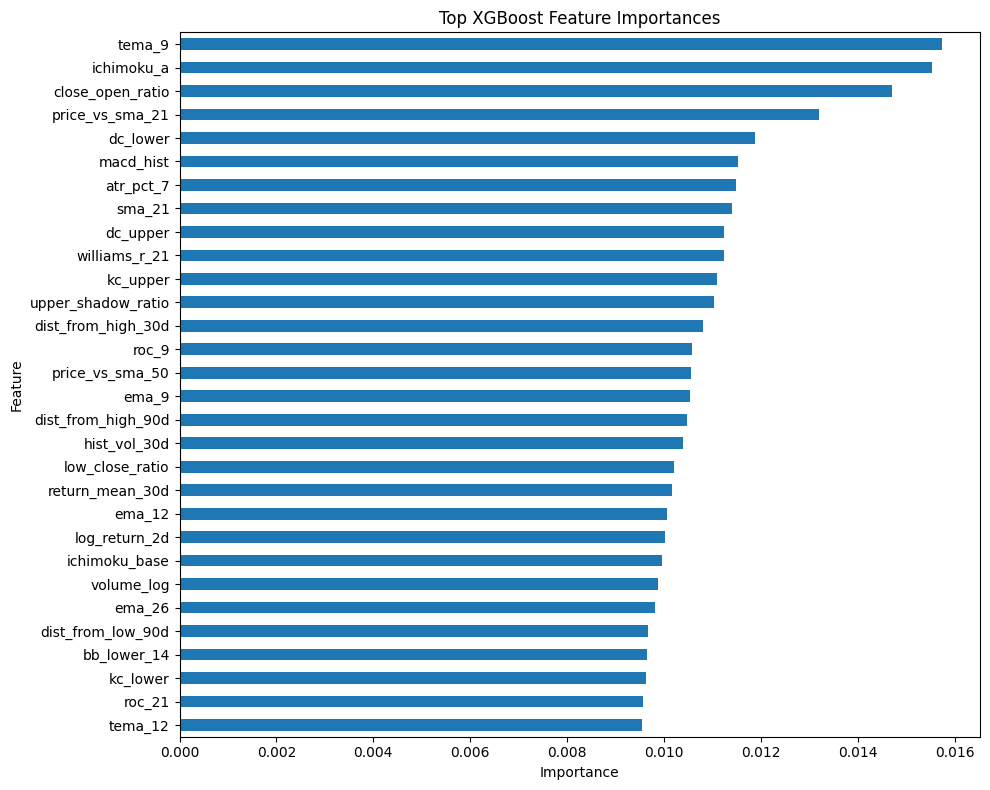

In [425]:
import matplotlib.pyplot as plt

top_n = 30

importance_df.head(top_n).sort_values("importance").plot(
    x="feature",
    y="importance",
    kind="barh",
    figsize=(10, 8),
    legend=False
)

plt.title("Top XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

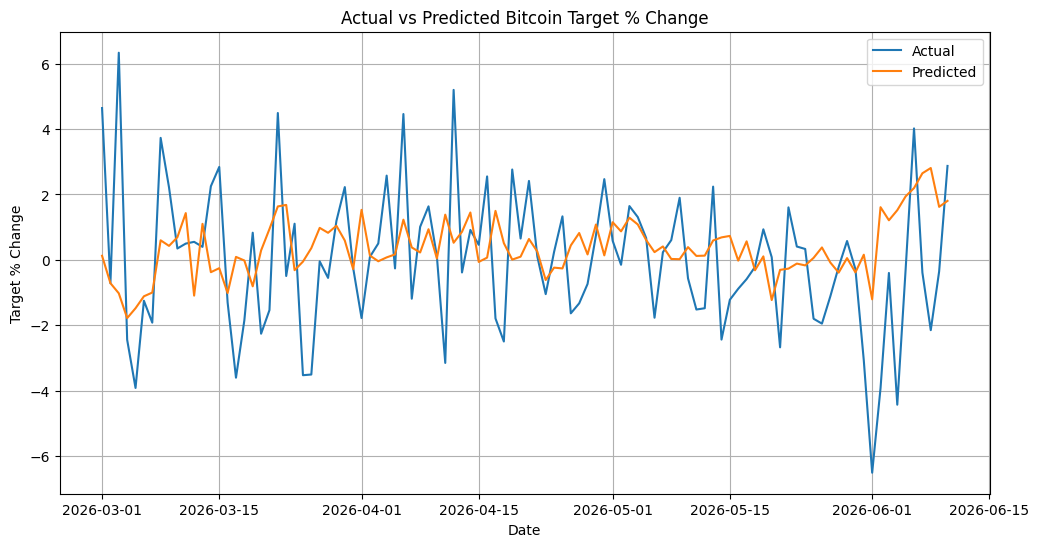

In [426]:
plt.figure(figsize=(12, 6))

plt.plot(comparison.index, comparison["actual"], label="Actual")
plt.plot(comparison.index, comparison["predicted"], label="Predicted")

plt.title("Actual vs Predicted Bitcoin Target % Change")
plt.xlabel("Date")
plt.ylabel("Target % Change")
plt.legend()
plt.grid(True)
plt.show()

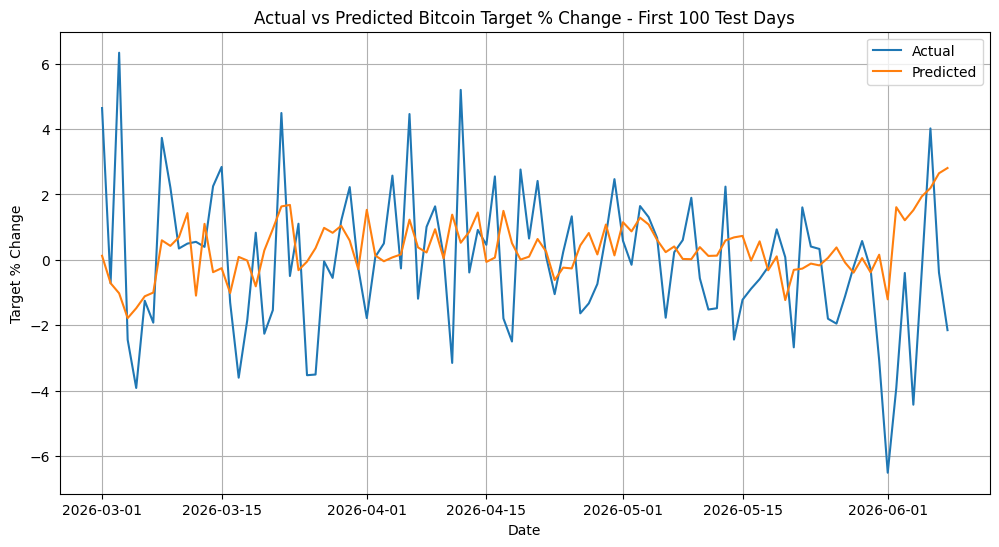

In [427]:
sample = comparison.head(100)

plt.figure(figsize=(12, 6))

plt.plot(sample.index, sample["actual"], label="Actual")
plt.plot(sample.index, sample["predicted"], label="Predicted")

plt.title("Actual vs Predicted Bitcoin Target % Change - First 100 Test Days")
plt.xlabel("Date")
plt.ylabel("Target % Change")
plt.legend()
plt.grid(True)
plt.show()

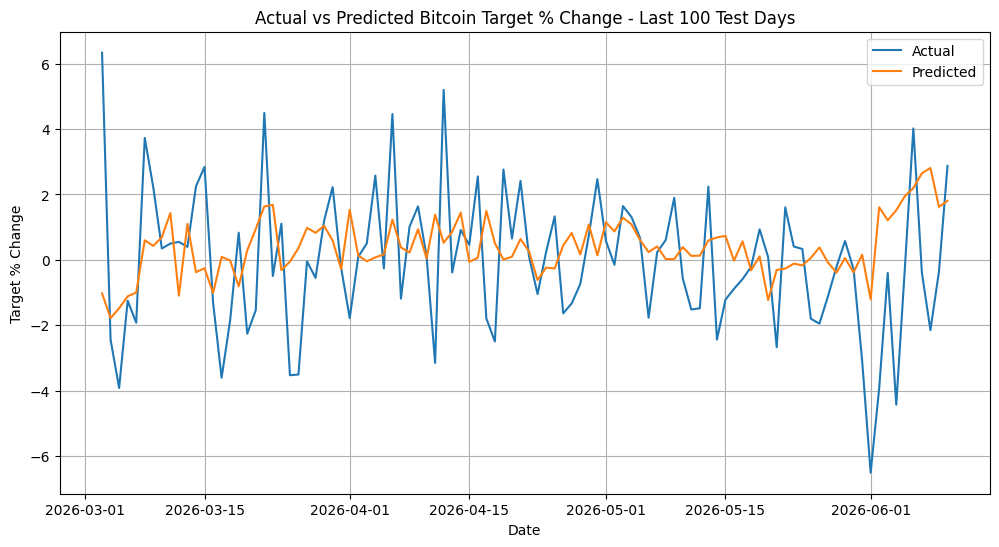

In [428]:
sample = comparison.tail(100)

plt.figure(figsize=(12, 6))

plt.plot(sample.index, sample["actual"], label="Actual")
plt.plot(sample.index, sample["predicted"], label="Predicted")

plt.title("Actual vs Predicted Bitcoin Target % Change - Last 100 Test Days")
plt.xlabel("Date")
plt.ylabel("Target % Change")
plt.legend()
plt.grid(True)
plt.show()